<a href="https://colab.research.google.com/github/areebaha/Women-Employment-Data/blob/main/Final_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part 2: Final

1) Problem statement: Describe what question(s) are you going to ask and the data you're using to ask them.

The questions we're asking are:

1a) What is the correlation between the sex demographics of majors and low-wage jobs? We are using the low wage jobs column and the men and women categories that make up total number of students for each major..

1b) How do major categories affect full-time and part-time employment? We are using the major categories column, and the full-time and part-time employment columns.

1c) How do majors affect employment rates? We will be using the major categories column and the employment and unemployment columns.

1d) Which major has the greatest amount of non-college jobs? We will be using the major categories and the non-college jobs column for this question.

2) Data processing: Load the dataset and perform any appropriate clean-up, selecting and/or renaming columns, filling in or filtering missing values, transforming values, etc. Briefly describe what your code is doing in text cells.

In [ ]:
%pip install -qq ipytest

import ipytest

ipytest.autoconfig()

from datascience import *

import numpy as np

import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use("fivethirtyeight")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.6 MB/s eta 0:00:00


In [ ]:
URL = "https://docs.google.com/spreadsheets/d/16YKbLsssrtzFqVNPe1oMSYaqXRwJ_YNWZdhbd7FGn88/export?format=csv"
college_grads = Table.read_table(URL)
college_grads

rank,major_code,major_name,total,men,women,major_type,share_women,sample_size,employed,full_time,part_time,full_time_year_round,unemployed,unemployment_rate,median,p25th,p75th,college_jobs,non_college_jobs,low_wage_jobs
1,2419,PETROLEUM ENGINEERING,2339,2057,282,Engineering,0.120564,36,1976,1849,270,1207,37,0.0183805,110000,95000,125000,1534,364,193
2,2416,MINING AND MINERAL ENGINEERING,756,679,77,Engineering,0.101852,7,640,556,170,388,85,0.117241,75000,55000,90000,350,257,50
3,2415,METALLURGICAL ENGINEERING,856,725,131,Engineering,0.153037,3,648,558,133,340,16,0.0240964,73000,50000,105000,456,176,0
4,2417,NAVAL ARCHITECTURE AND MARINE ENGINEERING,1258,1123,135,Engineering,0.107313,16,758,1069,150,692,40,0.0501253,70000,43000,80000,529,102,0
5,2405,CHEMICAL ENGINEERING,32260,21239,11021,Engineering,0.341631,289,25694,23170,5180,16697,1672,0.0610977,65000,50000,75000,18314,4440,972
6,2418,NUCLEAR ENGINEERING,2573,2200,373,Engineering,0.144967,17,1857,2038,264,1449,400,0.177226,65000,50000,102000,1142,657,244
7,6202,ACTUARIAL SCIENCE,3777,2110,1667,Business,0.441356,51,2912,2924,296,2482,308,0.0956522,62000,53000,72000,1768,314,259
8,5001,ASTRONOMY AND ASTROPHYSICS,1792,832,960,Physical Sciences,0.535714,10,1526,1085,553,827,33,0.0211674,62000,31500,109000,972,500,220
9,2414,MECHANICAL ENGINEERING,91227,80320,10907,Engineering,0.119559,1029,76442,71298,13101,54639,4650,0.0573423,60000,48000,70000,52844,16384,3253
10,2408,ELECTRICAL ENGINEERING,81527,65511,16016,Engineering,0.19645,631,61928,55450,12695,41413,3895,0.0591738,60000,45000,72000,45829,10874,3170


In [ ]:
URL = "https://docs.google.com/spreadsheets/d/1TF4ElD1swwec4H_nW0P4KxvaKJ3FucHupIUpeFoFiEE/export?format=csv"
cleaned_college_grads = Table.read_table(URL)
cleaned_college_grads

total,men,women,major_type,share_women,sample_size,employed,full_time,part_time,full_time_year_round,unemployed,college_jobs,non_college_jobs,low_wage_jobs
75620,40357,35263,Agriculture & Natural Resources,3.64741,1068,63794,55585,15470,41891,3486,18677,33217,7414
357130,134390,222740,Arts,4.82926,3260,288114,207773,114791,153111,28228,94785,163720,60116
453862,184919,268943,Biology & Life Science,8.2207,2317,302797,240377,116736,165802,22854,151233,127182,42742
1302376,667852,634524,Business,6.28157,15505,1088742,988870,196936,790425,79877,148538,496570,126788
392601,131921,260680,Communications & Journalism,2.63354,4508,330660,273330,89817,214228,26852,86556,172992,49595
299008,208725,90283,Computers & Mathematics,3.42949,2860,237894,207545,53270,159156,18373,137859,74463,16136
559129,103526,455603,Education,11.9761,4742,479839,398059,120593,288031,24969,338713,121761,40870
537583,408307,129276,Engineering,6.92777,4926,420372,381867,85136,288952,29817,269767,102383,25079
463230,75517,387713,Health,9.54182,3914,372147,294819,114592,228418,22213,245441,110496,31270
713468,272846,440622,Humanities & Liberal Arts,9.47686,5340,544118,416939,214030,295561,51101,192650,276532,94240


3) Analysis: Answer the question(s) you posed, including at least two different kinds of visualizations (scatterplots, line graphs, bar charts, maps, etc.)

Question 1: What is the correlation between the sex demographics of majors and low-wage jobs?

In [ ]:
#I will create a filtered table with only the men, women, total, and low-wage jobs columns to answer this question.
sex_demographics_table = college_grads.select("men", "women", "total", "low_wage_jobs")
sex_demographics_table

men,women,total,low_wage_jobs
2057,282,2339,193
679,77,756,50
725,131,856,0
1123,135,1258,0
21239,11021,32260,972
2200,373,2573,244
2110,1667,3777,259
832,960,1792,220
80320,10907,91227,3253
65511,16016,81527,3170


In [ ]:
# I am going to remove any low wage jobs that have zero in them because then I can't find the proportion
#of women and men in that job, and it will affect my results.
filtered_sex_demo = sex_demographics_table.where("low_wage_jobs", lambda t: t > 0).sort("low_wage_jobs", True)
filtered_sex_demo

men,women,total,low_wage_jobs
86648,307087,393735,48207
173809,156118,329927,32395
111762,168947,280709,28339
78857,126354,205211,27968
70619,143377,213996,27440
132238,102352,234590,27320
58227,136446,194673,26503
93880,88741,182621,19803
80231,72593,152824,18404
78253,63698,141951,16839


In [ ]:
#I am creating a helper function that will help me create a ratio of the amount of women/total and men/total
#so I can compare both values to the amount of people in low-wage jobs.
def sex_demo_ratio(col1: str, col2: str) -> float:
    """This takes two columns as an input and returns the percent ratio of col1/col2."""
    return (col1 / col2) * 100

In [ ]:
#I applied the helper function to the women/total and men over total to get the  percentages of the men and women
#the make up the total.
sex_ratio = filtered_sex_demo.with_column("percent_women",
                                               filtered_sex_demo.apply(sex_demo_ratio,
                                                                            "women", "total"))
sex_ratio_both = sex_ratio.with_column("percent_men",
                                       sex_ratio.apply(sex_demo_ratio,
                                                       "men", "total"))
sex_ratio_both
# So far, we can tell that there might be a correlation between the sex demographics of
#majors and if they got low paying jobs. In the first 10 rows of the highest amount of low paying jobs,
#47-77% of women make up the low paying jobs while only 22-55% of men make up the low paying jobs.

men,women,total,low_wage_jobs,percent_women,percent_men
86648,307087,393735,48207,77.9933,22.0067
173809,156118,329927,32395,47.319,52.681
111762,168947,280709,28339,60.1858,39.8142
78857,126354,205211,27968,61.5727,38.4273
70619,143377,213996,27440,66.9999,33.0001
132238,102352,234590,27320,43.6302,56.3698
58227,136446,194673,26503,70.0898,29.9102
93880,88741,182621,19803,48.593,51.407
80231,72593,152824,18404,47.501,52.499
78253,63698,141951,16839,44.8732,55.1268


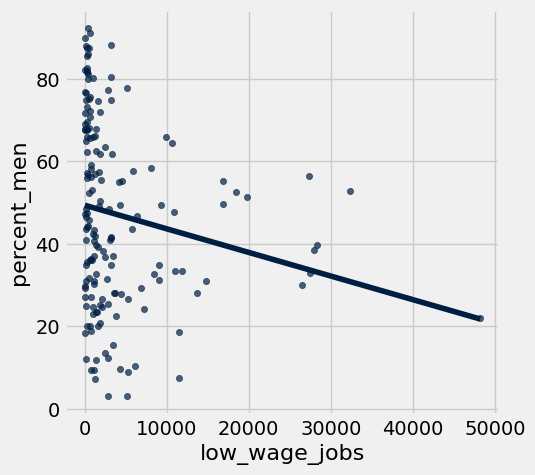

In [ ]:
sex_ratio_both.scatter("low_wage_jobs", "percent_men", fit_line = True)
#This scatterplot has a decreasing line of best fit, indicating that as the number of people
#in low wage jobs increases, the percentage of men decreases.

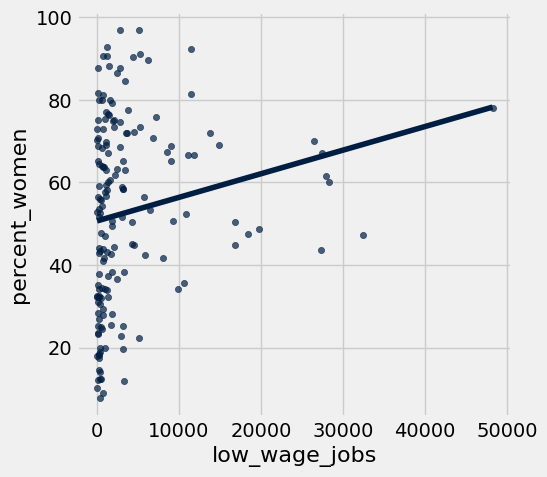

In [ ]:
sex_ratio_both.scatter("low_wage_jobs", "percent_women", fit_line = True)
#This scatterplot has a positively increasing line of best fit, indicating that as the number of
#people in low wage jobs increases, the percentage of women increases.
#This results show a positive correlation between the sex demographics of the total students
# and the amount of those who get low wage jobs.
#Women tend to be in more low wage jobs than men.

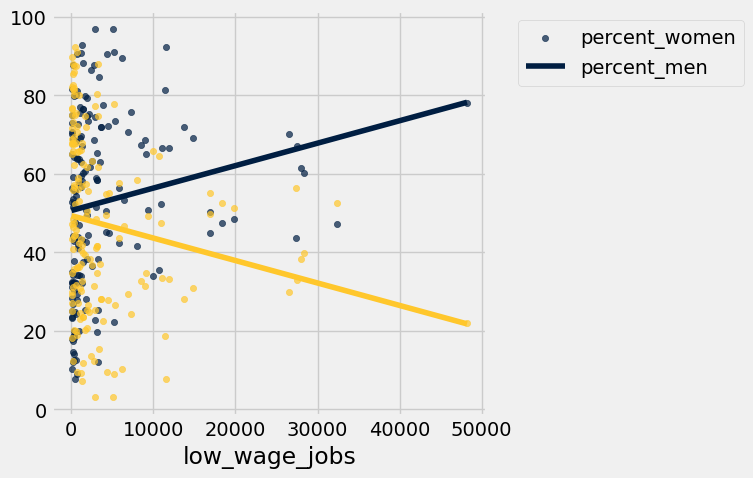

In [ ]:
sex_ratio_both.scatter("low_wage_jobs", ["percent_women", "percent_men"], fit_line = True)
#This graph shows the difference between the amount of men and women that get low wage jobs.
#There are more women that make up the low wage jobs than men.
#Note: The blue line actually represents percent_women, yellow line represents percent_men.

Question 2: Which major has the greatest amount of non-college jobs?

In [ ]:
#%%ipytest
#lowercase_table = [t.title() for t in cleaned_college_grads.column("major_name")]

#non_college_jobs = cleaned_college_grads.with_column("major_name", lowercase_table)
#non_college_jobs

In [ ]:
non_college_job_table = cleaned_college_grads.select("major_type", "college_jobs", "non_college_jobs").sort("non_college_jobs", True)
non_college_job_table

major_type,college_jobs,non_college_jobs
Business,148538,496570
Humanities & Liberal Arts,192650,276532
Social Science,113960,190246
Communications & Journalism,86556,172992
Psychology & Social Work,164305,169366
Arts,94785,163720
Biology & Life Science,151233,127182
Education,338713,121761
Health,245441,110496
Industrial Arts & Consumer Services,57200,104620


In [ ]:
%%ipytest
def helper_jobs_column(num1: int, num2: int) -> int:
    """This takes in a number and divides it by the sum of two numbers."""
    return (num1 / (num1 + num2)) * 100

percent_non_college_jobs = non_college_job_table.with_column("%ncj/total",
                                                        non_college_job_table.apply(helper_jobs_column,
                                                                                    "non_college_jobs", "college_jobs"))

percent_non_college_jobs

major_type,college_jobs,non_college_jobs,%ncj/total
Business,148538,496570,76.9747
Humanities & Liberal Arts,192650,276532,58.9392
Social Science,113960,190246,62.5385
Communications & Journalism,86556,172992,66.6513
Psychology & Social Work,164305,169366,50.7584
Arts,94785,163720,63.3334
Biology & Life Science,151233,127182,45.6807
Education,338713,121761,26.4425
Health,245441,110496,31.0437
Industrial Arts & Consumer Services,57200,104620,64.6521



no tests ran in 0.00s


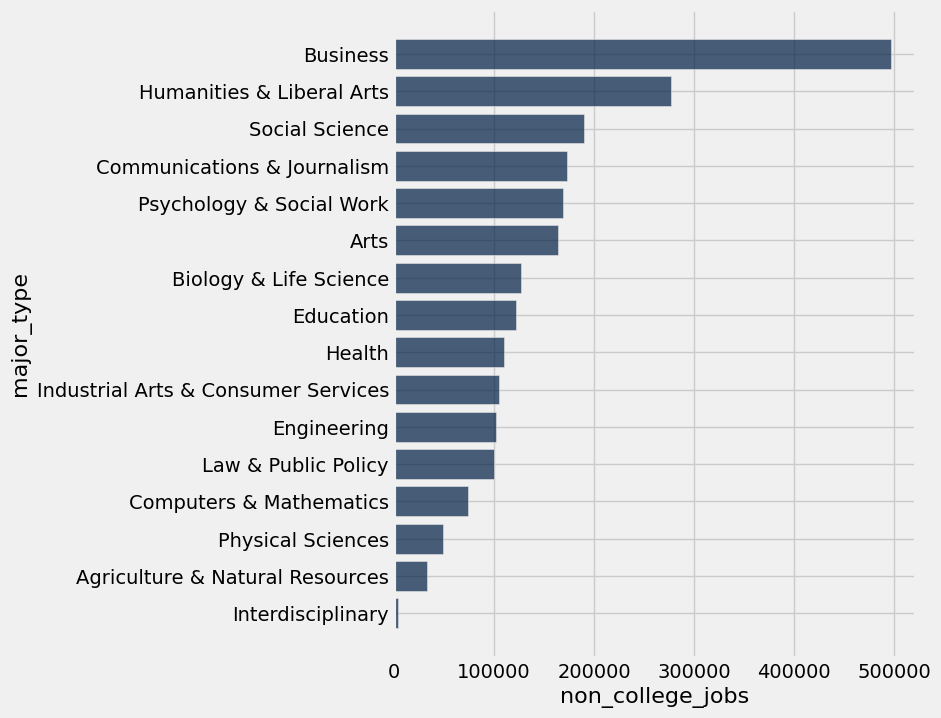

In [ ]:
percent_non_college_jobs.barh("major_type", "non_college_jobs")
#This shows that Business major college grads have the largest number of non-college jobs.

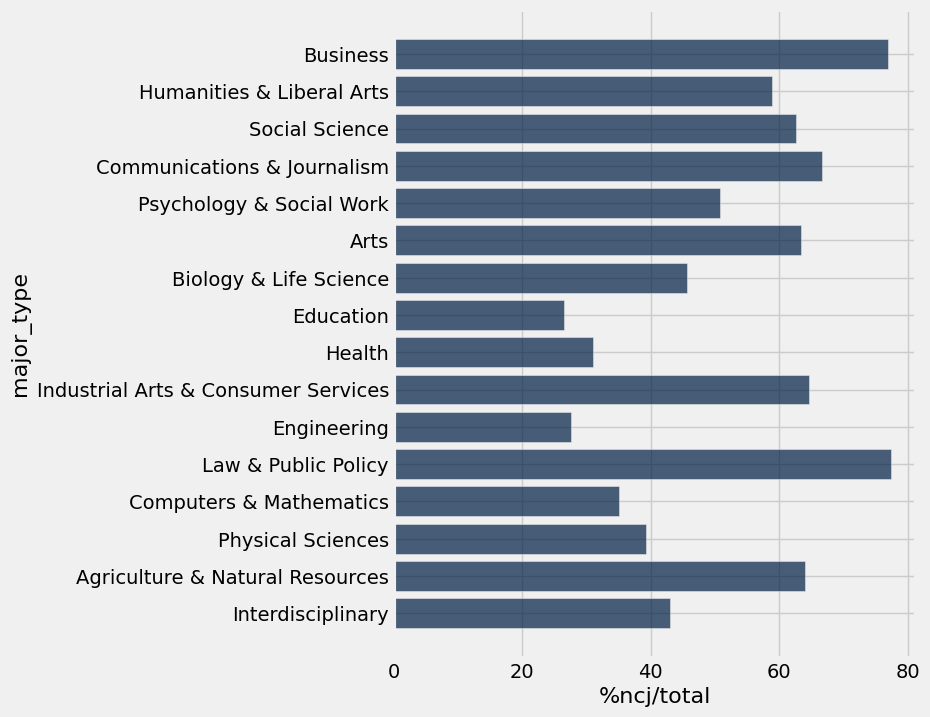

In [ ]:
percent_non_college_jobs.barh("major_type", "%ncj/total")
#Out of the total number of college and non-college jobs, Business majors still have the largest percent
# of non_college_jobs.

4) References: Cite any resources you used. At a minimum, this should include where you got the data set from.